***Cell 1: Import libraries***

In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


***Cell 2: Load weather dataset***

In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm

data_path = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy4\dailyWeatherDataForVietnameseProvinces_63pro_1years.csv"

df = pd.read_csv(data_path)

print("Shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())

print("\nCác loại thời tiết (day.condition.text) xuất hiện:")
print(df["day.condition.text"].value_counts().head(20))
print("Tổng số loại thời tiết:", df["day.condition.text"].nunique())


Shape: (26018, 34)


,location.name,location.region,location.terrain,location.country,location.lat,location.lon,date,date_epoch,day.maxtemp_c,day.maxtemp_f,...,day.condition.text,day.condition.icon,day.condition.code,day.uv,astro.sunrise,astro.sunset,astro.moonrise,astro.moonset,astro.moon_phase,astro.moon_illumination
0,An Giang,Đồng Bằng Sông Cửu Long,đồng bằng,Vietnam,10.7000,105.1167,2024-04-21,1713657600,38.6,101.5,...,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,9.0,05:46 AM,06:11 PM,04:13 PM,03:55 AM,Waxing Gibbous,90
1,Bà Rịa-Vũng Tàu,Đông Nam Bộ,ven biển,Vietnam,10.3500,107.0667,2024-04-21,1713657600,30.2,86.3,...,Moderate rain at times,//cdn.weatherapi.com/weather/64x64/day/299.png,1186,7.0,05:38 AM,06:03 PM,04:05 PM,03:47 AM,Waxing Gibbous,90
2,Bắc Giang,Trung du và miền núi Bắc Bộ,miền núi,Vietnam,21.2667,106.2000,2024-04-21,1713657600,31.9,89.4,...,Heavy rain at times,//cdn.weatherapi.com/weather/64x64/day/305.png,1192,7.0,05:32 AM,06:16 PM,04:09 PM,03:53 AM,Waxing Gibbous,90
3,Bắc Kạn,Trung du và miền núi Bắc Bộ,miền núi,Vietnam,22.1333,105.8333,2024-04-21,1713657600,28.0,82.5,...,Moderate or heavy rain shower,//cdn.weatherapi.com/weather/64x64/day/356.png,1243,6.0,05:32 AM,06:19 PM,04:10 PM,03:54 AM,Waxing Gibbous,90
4,Bạc Liêu,Đồng Bằng Sông Cửu Long,ven biển,Vietnam,9.2850,105.7244,2024-04-21,1713657600,36.1,97.1,...,Partly cloudy,//cdn.weatherapi.com/weather/64x64/day/116.png,1003,9.0,05:45 AM,06:07 PM,04:11 PM,03:52 AM,Waxing Gibbous,90


Columns: ['location.name', 'location.region', 'location.terrain', 'location.country', 'location.lat', 'location.lon', 'date', 'date_epoch', 'day.maxtemp_c', 'day.maxtemp_f', 'day.mintemp_c', 'day.mintemp_f', 'day.avgtemp_c', 'day.avgtemp_f', 'day.maxwind_mph', 'day.maxwind_kph', 'day.totalprecip_mm', 'day.totalprecip_in', 'day.totalsnow_cm', 'day.avgvis_km', 'day.avgvis_miles', 'day.avghumidity', 'day.daily_will_it_rain', 'day.daily_chance_of_rain', 'day.condition.text', 'day.condition.icon', 'day.condition.code', 'day.uv', 'astro.sunrise', 'astro.sunset', 'astro.moonrise', 'astro.moonset', 'astro.moon_phase', 'astro.moon_illumination']

Các loại thời tiết (day.condition.text) xuất hiện:
day.condition.text
Moderate or heavy rain shower          7282
Patchy rain possible                   6136
Overcast                               2640
Moderate rain at times                 2069
Partly cloudy                          2016
Sunny                                  1526
Heavy rain at times 

***Cell 3: Parse date & encode weather condition labels***

In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm

# 1. Chuyển cột date sang datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
df = df.sort_values(["location.name", "date"]).reset_index(drop=True)

# 2. Encode label cho loại thời tiết (condition.text)
label_encoder = LabelEncoder()
df["condition_label"] = label_encoder.fit_transform(df["day.condition.text"])

num_classes = df["condition_label"].nunique()
print("Số lớp (weather condition):", num_classes)

print("\nMapping label (số -> text) mẫu:")
for i, cls in enumerate(label_encoder.classes_[:10]):
    print(i, "->", cls)


Số lớp (weather condition): 21

Mapping label (số -> text) mẫu:
0 -> Cloudy
1 -> Fog
2 -> Heavy rain
3 -> Heavy rain at times
4 -> Light drizzle
5 -> Light rain
6 -> Light rain shower
7 -> Mist
8 -> Moderate or heavy rain shower
9 -> Moderate or heavy rain with thunder


***Cell 4: Create "next day's weather" label per province***

In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm
groups = []
for loc, g in df.groupby("location.name"):
    g = g.sort_values("date")
    # nhãn là thời tiết ngày mai
    g["next_condition_label"] = g["condition_label"].shift(-1)
    # bỏ dòng cuối vì không có nhãn ngày mai
    g = g.iloc[:-1]
    groups.append(g)

df_seq = pd.concat(groups, axis=0).reset_index(drop=True)

print("Shape sau khi tạo nhãn ngày mai:", df_seq.shape)
display(df_seq[["location.name", "date", "day.condition.text", "next_condition_label"]].head())

print("\nPhân bố label (next_condition_label):")
print(df_seq["next_condition_label"].value_counts().head(20))


Shape sau khi tạo nhãn ngày mai: (25955, 36)


,location.name,date,day.condition.text,next_condition_label
0,An Giang,2024-04-21,Sunny,18.0
1,An Giang,2024-04-22,Sunny,18.0
2,An Giang,2024-04-23,Sunny,0.0
3,An Giang,2024-04-24,Cloudy,12.0
4,An Giang,2024-04-25,Overcast,11.0



Phân bố label (next_condition_label):
next_condition_label
8.0     7272
17.0    6118
12.0    2636
11.0    2065
13.0    2004
18.0    1520
3.0     1427
0.0     1224
6.0     1022
16.0     202
19.0     180
14.0     111
4.0       58
15.0      40
1.0       29
9.0       14
5.0       10
20.0      10
7.0        7
10.0       5
Name: count, dtype: int64


***Cell 5: Data distribution visualization***

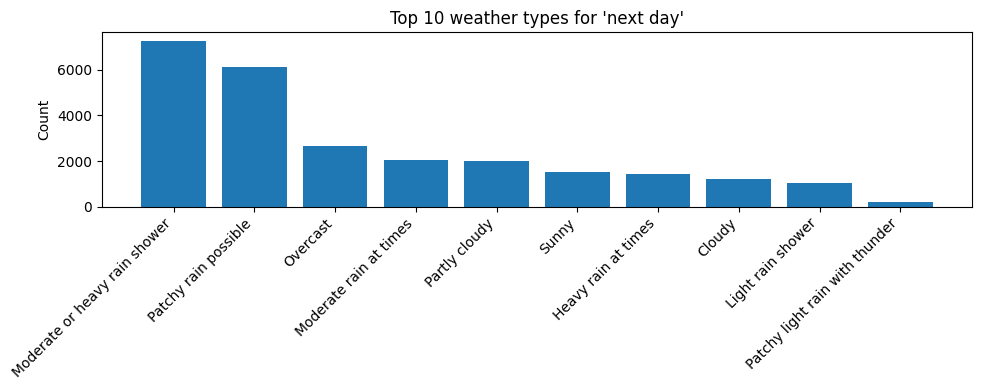

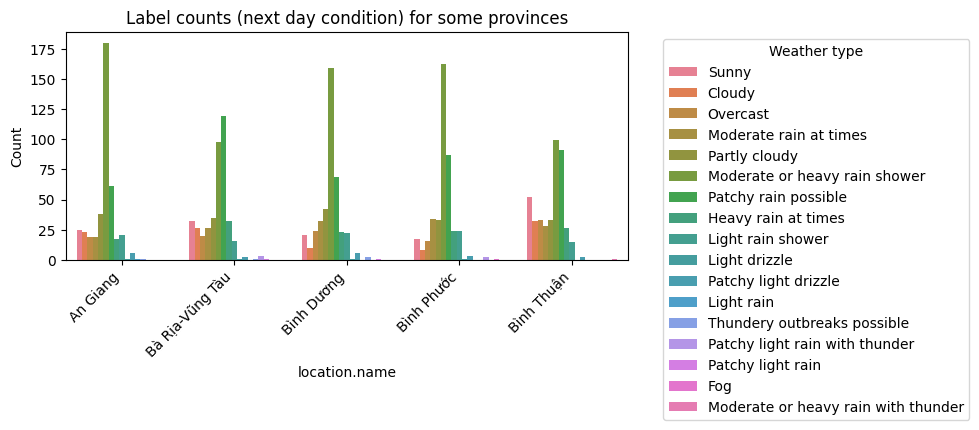

In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm

# 1. Top 10 loại thời tiết phổ biến cho "next_condition_label"
vc = (
    df_seq["next_condition_label"]
    .dropna()                    # bỏ NaN nếu còn
    .astype(int)                 # đảm bảo là int
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

# Đổi id -> text
top_ids = vc.index.to_numpy()
top_counts = vc.values
top_texts = label_encoder.inverse_transform(top_ids)

plt.figure(figsize=(10, 4))
plt.bar(top_texts, top_counts)
plt.title("Top 10 weather types for 'next day'")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Phân bố theo một vài tỉnh (random 5 tỉnh đầu tiên)
sample_locs = df_seq["location.name"].unique()[:5]

tmp = df_seq[df_seq["location.name"].isin(sample_locs)].copy()
tmp = tmp[tmp["next_condition_label"].notna()]            # bỏ NaN nếu có
tmp["next_condition_label"] = tmp["next_condition_label"].astype(int)
tmp["next_condition_text"] = label_encoder.inverse_transform(
    tmp["next_condition_label"].to_numpy()
)

plt.figure(figsize=(10, 4))
sns.countplot(
    data=tmp,
    x="location.name",
    hue="next_condition_text"
)
plt.title("Label counts (next day condition) for some provinces")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Weather type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


***Cell 6: Make time-series sequences (lookback=7 days)***

In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm

LOOKBACK = 7

# Chọn feature numeric hữu ích
feature_cols = [
    "day.maxtemp_c",
    "day.mintemp_c",
    "day.avgtemp_c",
    "day.totalprecip_mm",
    "day.avghumidity",
    "day.maxwind_kph",
    "day.uv",
    "day.daily_chance_of_rain"
]

# Đảm bảo các cột tồn tại
feature_cols = [c for c in feature_cols if c in df_seq.columns]
print("Feature columns sử dụng:", feature_cols)

# Điền NaN cho feature (nếu có) bằng median
df_seq[feature_cols] = df_seq[feature_cols].fillna(df_seq[feature_cols].median())

def make_sequences_for_location(g, feature_cols, lookback):
    g = g.sort_values("date")
    feats = g[feature_cols].values
    labels = g["next_condition_label"].values
    X, y = [], []
    for i in range(len(feats) - lookback + 1):
        X.append(feats[i:i+lookback])
        y.append(labels[i+lookback-1])
    return np.array(X), np.array(y)

X_list, y_list = [], []

for loc, g in df_seq.groupby("location.name"):
    X_loc, y_loc = make_sequences_for_location(g, feature_cols, LOOKBACK)
    if len(X_loc) == 0:
        continue
    X_list.append(X_loc)
    y_list.append(y_loc)

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)

print("Tổng số sequence:")
print("X_all:", X_all.shape)  # (N, 7, num_features)
print("y_all:", y_all.shape)


Feature columns sử dụng: ['day.maxtemp_c', 'day.mintemp_c', 'day.avgtemp_c', 'day.totalprecip_mm', 'day.avghumidity', 'day.maxwind_kph', 'day.uv', 'day.daily_chance_of_rain']
Tổng số sequence:
X_all: (25577, 7, 8)
y_all: (25577,)


***Cell 7: Train/Val/Test split & scaling***

In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm

n_total = len(X_all)
train_end = int(0.7 * n_total)
val_end   = int(0.85 * n_total)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:], y_all[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)

n_features = X_all.shape[2]

# Chuẩn hoá theo feature (fit trên train)
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, n_features)
X_val_flat   = X_val.reshape(-1, n_features)
X_test_flat  = X_test.reshape(-1, n_features)

X_train_scaled_flat = scaler.fit_transform(X_train_flat)
X_val_scaled_flat   = scaler.transform(X_val_flat)
X_test_scaled_flat  = scaler.transform(X_test_flat)

X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
X_val_scaled   = X_val_scaled_flat.reshape(X_val.shape)
X_test_scaled  = X_test_scaled_flat.reshape(X_test.shape)

print("Scaled shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)


Train: (17903, 7, 8) (17903,)
Val  : (3837, 7, 8) (3837,)
Test : (3837, 7, 8) (3837,)
Scaled shapes: (17903, 7, 8) (3837, 7, 8) (3837, 7, 8)


***Cell 8: Build RNN model (SimpleRNN, >=7 layers)***

In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm

input_shape = (LOOKBACK, n_features)

def build_rnn_model(num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),                          # 1
        layers.SimpleRNN(64, return_sequences=True),              # 2
        layers.SimpleRNN(64, return_sequences=True),              # 3
        layers.Dropout(0.3),                                     # 4
        layers.SimpleRNN(32),                                    # 5
        layers.Dense(64, activation="relu"),                     # 6
        layers.Dense(32, activation="relu"),                     # 7
        layers.Dense(num_classes, activation="softmax")          # 8
    ])
    return model

rnn_model = build_rnn_model(num_classes)
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 7, 64)               │           4,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 7, 64)               │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,917 (81.71 KB)

 Trainable params: 20,917 (81.71 KB)

 Non-trainable params: 0 (0.00 B)

***Cell 9: Train RNN model***

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm
BATCH_SIZE = 64
EPOCHS = 100

history_rnn = rnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5447 - loss: 1.3175 - val_accuracy: 0.5158 - val_loss: 1.4744
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5468 - loss: 1.2976 - val_accuracy: 0.5106 - val_loss: 1.4824
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5466 - loss: 1.2947 - val_accuracy: 0.5087 - val_loss: 1.4939
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5500 - loss: 1.2905 - val_accuracy: 0.5160 - val_loss: 1.4869
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5501 - loss: 1.2848 - val_accuracy: 0.5147 - val_loss: 1.4983
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5614 - loss: 1.2635 - val_accuracy: 0.5168 - val_loss: 1.4843
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5588 - loss: 1.2685 - val_accuracy: 0.5189 - val_loss: 1.4860
Epoch 8/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5597 - loss: 1.2646 - val_accu

***Cell 10: Visualize RNN metrics (loss & accuracy)***

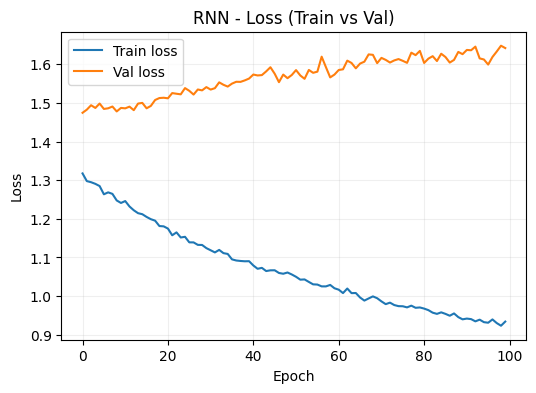

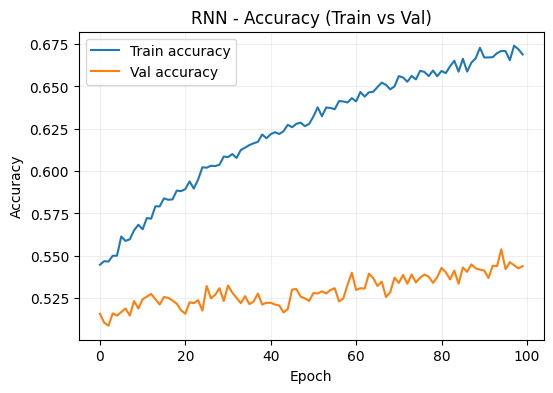

In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm

def plot_metric(history, metric_name, title, ylabel=None):
    if ylabel is None:
        ylabel = metric_name.upper()
    plt.figure(figsize=(6,4))
    plt.plot(history.history[metric_name], label=f"Train {metric_name}")
    plt.plot(history.history[f"val_{metric_name}"], label=f"Val {metric_name}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_metric(history_rnn, "loss", "RNN - Loss (Train vs Val)", ylabel="Loss")
plot_metric(history_rnn, "accuracy", "RNN - Accuracy (Train vs Val)", ylabel="Accuracy")


***Cell 11: Evaluate RNN model on test set***

RNN Test Loss: 1.7640
RNN Test Acc : 0.5066


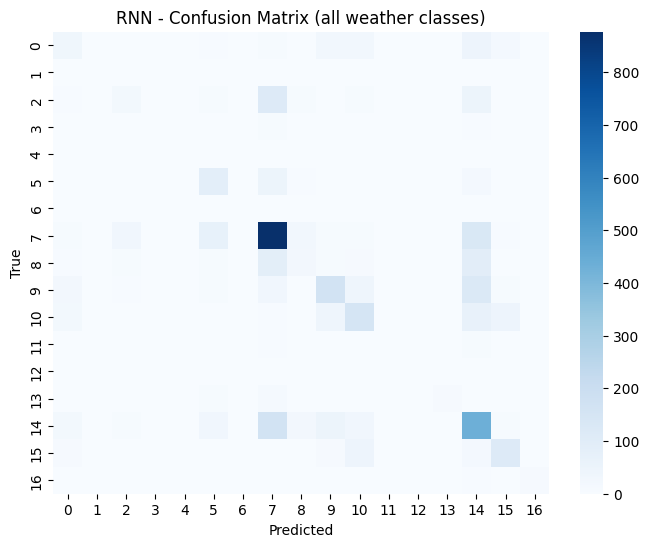

RNN - Classification report (cắt 10 lớp đầu tiên nếu quá dài):
              precision    recall  f1-score   support

         0.0       0.27      0.21      0.24       172
         1.0       0.00      0.00      0.00         4
         3.0       0.29      0.11      0.16       217
         4.0       0.00      0.00      0.00        16
         5.0       0.00      0.00      0.00         4
         6.0       0.38      0.54      0.45       164
         7.0       0.00      0.00      0.00         1
         8.0       0.63      0.75      0.69      1170
        11.0       0.25      0.11      0.15       256
        12.0       0.52      0.40      0.46       412
        13.0       0.46      0.45      0.46       340
        14.0       0.00      0.00      0.00        20
        15.0       0.00      0.00      0.00        10
        16.0       0.85      0.30      0.44        37
        17.0       0.43      0.55      0.48       784
        18.0       0.57      0.56      0.56       209
        19.0      

In [13]:
#B22DCCN476 - Đỗ Ngọc Lâm

test_loss_rnn, test_acc_rnn = rnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"RNN Test Loss: {test_loss_rnn:.4f}")
print(f"RNN Test Acc : {test_acc_rnn:.4f}")

y_prob_rnn = rnn_model.predict(X_test_scaled, verbose=0)
y_pred_rnn = np.argmax(y_prob_rnn, axis=1)

cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rnn, cmap="Blues", cbar=True)
plt.title("RNN - Confusion Matrix (all weather classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("RNN - Classification report (cắt 10 lớp đầu tiên nếu quá dài):")
print(classification_report(y_test, y_pred_rnn, zero_division=0))


***Cell 12: Build LSTM model (>=7 layers)***

In [14]:
#B22DCCN476 - Đỗ Ngọc Lâm

def build_lstm_model(num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),                 # 1
        layers.LSTM(64, return_sequences=True),          # 2
        layers.LSTM(64, return_sequences=True),          # 3
        layers.Dropout(0.3),                             # 4
        layers.LSTM(32),                                 # 5
        layers.Dense(64, activation="relu"),             # 6
        layers.Dense(32, activation="relu"),             # 7
        layers.Dense(num_classes, activation="softmax")  # 8
    ])
    return model

lstm_model = build_lstm_model(num_classes)
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 64)               │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 7, 64)               │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,013 (269.58 KB)

 Trainable params: 69,013 (269.58 KB)

 Non-trainable params: 0 (0.00 B)

***Cell 13: Train LSTM model***

In [15]:
#B22DCCN476 - Đỗ Ngọc Lâm

history_lstm = lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3501 - loss: 2.0177 - val_accuracy: 0.3969 - val_loss: 1.8186
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3977 - loss: 1.7760 - val_accuracy: 0.4347 - val_loss: 1.6938
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4156 - loss: 1.7306 - val_accuracy: 0.4449 - val_loss: 1.6692
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4203 - loss: 1.7088 - val_accuracy: 0.4537 - val_loss: 1.6508
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4261 - loss: 1.6910 - val_accuracy: 0.4610 - val_loss: 1.6308
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4292 - loss: 1.6748 - val_accuracy: 0.4590 - val_loss: 1.6153
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4346 - loss: 1.6568 - val_accuracy: 0.4623 - val_loss: 1.6029
Epoch 8/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4380 - loss: 1.6408 - val_accu

***Cell 14: Visualize LSTM metrics (loss & accuracy)***

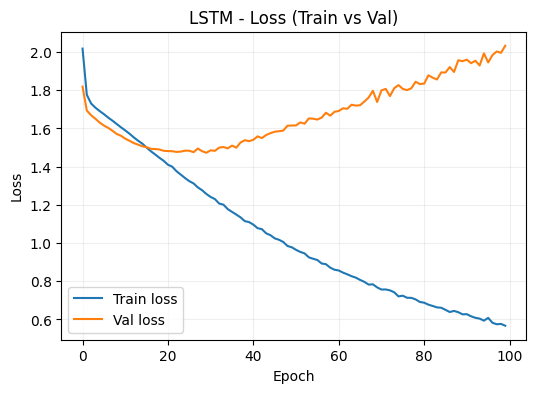

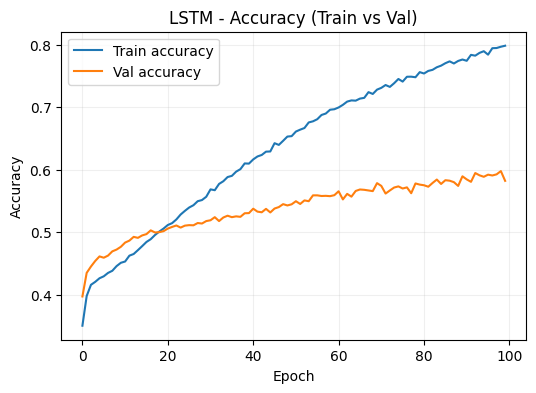

In [16]:
#B22DCCN476 - Đỗ Ngọc Lâm

plot_metric(history_lstm, "loss", "LSTM - Loss (Train vs Val)", ylabel="Loss")
plot_metric(history_lstm, "accuracy", "LSTM - Accuracy (Train vs Val)", ylabel="Accuracy")


***Cell 15: Evaluate LSTM model on test set***

LSTM Test Loss: 2.2170
LSTM Test Acc : 0.5648


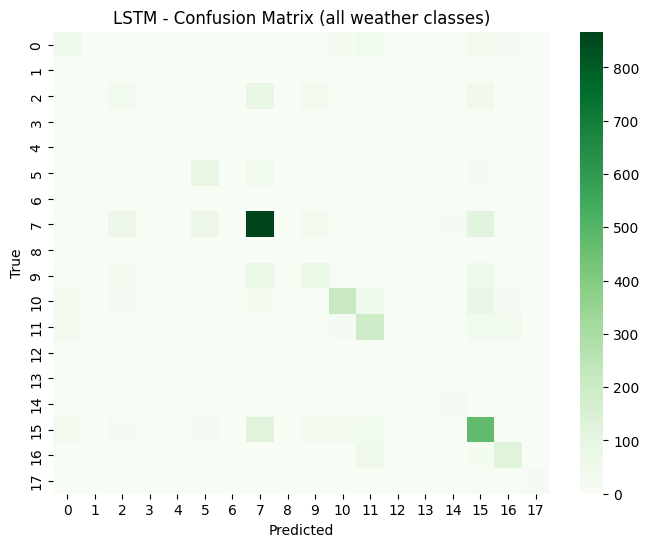

LSTM - Classification report:
              precision    recall  f1-score   support

         0.0       0.31      0.28      0.30       172
         1.0       0.00      0.00      0.00         4
         3.0       0.24      0.17      0.20       217
         4.0       0.43      0.19      0.26        16
         5.0       0.00      0.00      0.00         4
         6.0       0.47      0.57      0.52       164
         7.0       0.00      0.00      0.00         1
         8.0       0.69      0.74      0.72      1170
        10.0       0.00      0.00      0.00         0
        11.0       0.40      0.29      0.33       256
        12.0       0.70      0.52      0.60       412
        13.0       0.51      0.56      0.53       340
        14.0       0.25      0.15      0.19        20
        15.0       0.14      0.20      0.17        10
        16.0       0.42      0.51      0.46        37
        17.0       0.53      0.60      0.56       784
        18.0       0.62      0.61      0.61       2

In [17]:
#B22DCCN476 - Đỗ Ngọc Lâm

test_loss_lstm, test_acc_lstm = lstm_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"LSTM Test Loss: {test_loss_lstm:.4f}")
print(f"LSTM Test Acc : {test_acc_lstm:.4f}")

y_prob_lstm = lstm_model.predict(X_test_scaled, verbose=0)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lstm, cmap="Greens", cbar=True)
plt.title("LSTM - Confusion Matrix (all weather classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("LSTM - Classification report:")
print(classification_report(y_test, y_pred_lstm, zero_division=0))


***Cell 16: Build + train regularized LSTM to reduce overfitting***

In [20]:
#B22DCCN476 - Đỗ Ngọc Lâm

from tensorflow.keras import regularizers

input_shape = (LOOKBACK, n_features)

def build_reg_lstm_model(num_classes):
    reg = regularizers.l2(1e-3)  # L2 regularization
    model = models.Sequential([
        layers.Input(shape=input_shape),                          # 1
        layers.LSTM(64, return_sequences=True,
                   kernel_regularizer=reg, recurrent_regularizer=reg),  # 2
        layers.Dropout(0.2),                                      # 3
        layers.LSTM(64, return_sequences=True,
                   kernel_regularizer=reg, recurrent_regularizer=reg),  # 4
        layers.Dropout(0.2),                                      # 5
        layers.LSTM(32, kernel_regularizer=reg,
                   recurrent_regularizer=reg),                    # 6
        layers.Dense(64, activation="relu", kernel_regularizer=reg),    # 7
        layers.Dropout(0.2),                                      # 8
        layers.Dense(32, activation="relu", kernel_regularizer=reg),    # 9
        layers.Dense(num_classes, activation="softmax")           # 10
    ])
    return model

reg_lstm_model = build_reg_lstm_model(num_classes)

reg_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

reg_lstm_model.summary()

# EarlyStopping + ReduceLROnPlateau để tránh overfit
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)

EPOCHS_REG = 100  # cho phép lớn, EarlyStopping sẽ dừng sớm

history_reg_lstm = reg_lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS_REG,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                        │ (None, 7, 64)               │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 7, 64)               │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,013 (269.58 KB)

 Trainable params: 69,013 (269.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3428 - loss: 2.2442 - val_accuracy: 0.3901 - val_loss: 1.9636 - learning_rate: 0.0010
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3772 - loss: 1.9480 - val_accuracy: 0.4222 - val_loss: 1.8523 - learning_rate: 0.0010
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3966 - loss: 1.8788 - val_accuracy: 0.4300 - val_loss: 1.8125 - learning_rate: 0.0010
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4048 - loss: 1.8520 - val_accuracy: 0.4334 - val_loss: 1.7920 - learning_rate: 0.0010
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4065 - loss: 1.8373 - val_accuracy: 0.4334 - val_loss: 1.7794 - learning_rate: 0.0010
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4083 - loss: 1.8242 - val_accuracy: 0.4342 - val_loss: 1.7694 - learning_rate: 0.0010
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4120 - loss: 1.

***Cell 17: Visualize regularized LSTM metrics***

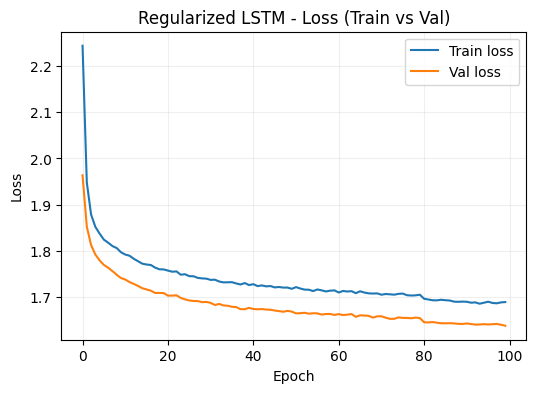

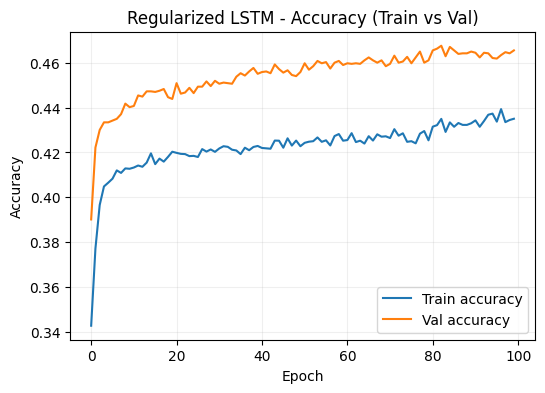

In [21]:
#B22DCCN476 - Đỗ Ngọc Lâm

def plot_metric(history, metric_name, title, ylabel=None):
    if ylabel is None:
        ylabel = metric_name.upper()
    plt.figure(figsize=(6,4))
    plt.plot(history.history[metric_name], label=f"Train {metric_name}")
    plt.plot(history.history[f"val_{metric_name}"], label=f"Val {metric_name}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_metric(history_reg_lstm, "loss",
            "Regularized LSTM - Loss (Train vs Val)", ylabel="Loss")
plot_metric(history_reg_lstm, "accuracy",
            "Regularized LSTM - Accuracy (Train vs Val)", ylabel="Accuracy")


***Cell 18: Evaluate regularized LSTM on test set***

Regularized LSTM Test Loss: 1.6804
Regularized LSTM Test Acc : 0.4449


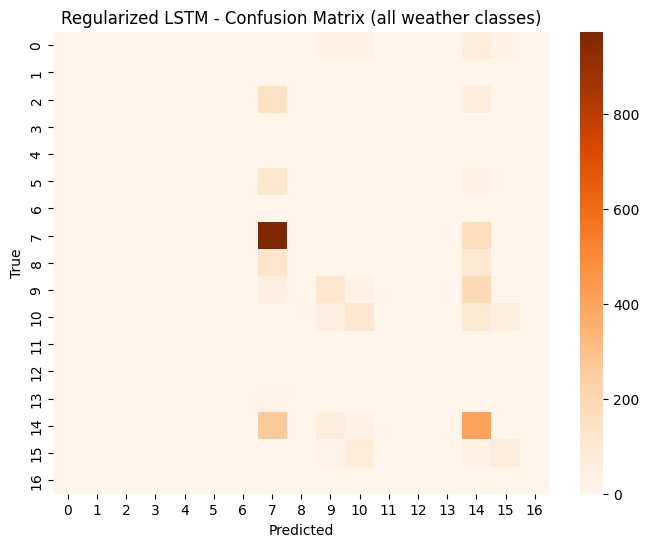

Regularized LSTM - Classification report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       172
         1.0       0.00      0.00      0.00         4
         3.0       0.00      0.00      0.00       217
         4.0       0.00      0.00      0.00        16
         5.0       0.00      0.00      0.00         4
         6.0       0.33      0.07      0.12       164
         7.0       0.00      0.00      0.00         1
         8.0       0.55      0.83      0.66      1170
        11.0       0.00      0.00      0.00       256
        12.0       0.39      0.29      0.34       412
        13.0       0.36      0.34      0.35       340
        14.0       0.00      0.00      0.00        20
        15.0       0.00      0.00      0.00        10
        16.0       0.00      0.00      0.00        37
        17.0       0.34      0.52      0.41       784
        18.0       0.42      0.35      0.38       209
        19.0       0.25      0.29      

In [22]:
#B22DCCN476 - Đỗ Ngọc Lâm

test_loss_reg, test_acc_reg = reg_lstm_model.evaluate(
    X_test_scaled, y_test, verbose=0
)
print(f"Regularized LSTM Test Loss: {test_loss_reg:.4f}")
print(f"Regularized LSTM Test Acc : {test_acc_reg:.4f}")

y_prob_reg = reg_lstm_model.predict(X_test_scaled, verbose=0)
y_pred_reg = np.argmax(y_prob_reg, axis=1)

cm_reg = confusion_matrix(y_test, y_pred_reg)

plt.figure(figsize=(8,6))
sns.heatmap(cm_reg, cmap="Oranges", cbar=True)
plt.title("Regularized LSTM - Confusion Matrix (all weather classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Regularized LSTM - Classification report:")
print(classification_report(y_test, y_pred_reg, zero_division=0))


***Cell 19: Compare RNN vs LSTM vs Regularized LSTM***

Test accuracy:
RNN       : 0.5066
LSTM      : 0.5648
Reg-LSTM  : 0.4449

Test loss:
RNN       : 1.7640
LSTM      : 2.2170
Reg-LSTM  : 1.6804


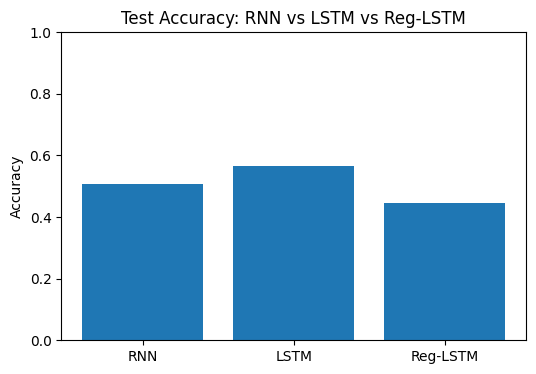

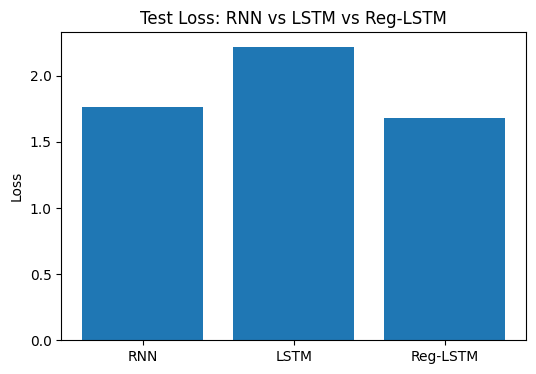


👉 Best model selected: LSTM


In [24]:
#B22DCCN476 - Đỗ Ngọc Lâm

model_names = ["RNN", "LSTM", "Reg-LSTM"]
acc_values  = [test_acc_rnn, test_acc_lstm, test_acc_reg]
loss_values = [test_loss_rnn, test_loss_lstm, test_loss_reg]

print("Test accuracy:")
for name, acc in zip(model_names, acc_values):
    print(f"{name:10s}: {acc:.4f}")

print("\nTest loss:")
for name, loss in zip(model_names, loss_values):
    print(f"{name:10s}: {loss:.4f}")

# Bar chart accuracy
plt.figure(figsize=(6,4))
plt.bar(model_names, acc_values)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Test Accuracy: RNN vs LSTM vs Reg-LSTM")
plt.show()

# Bar chart loss
plt.figure(figsize=(6,4))
plt.bar(model_names, loss_values)
plt.ylabel("Loss")
plt.title("Test Loss: RNN vs LSTM vs Reg-LSTM")
plt.show()

# Chọn mô hình tốt nhất: ưu tiên acc cao, nếu bằng thì loss thấp hơn
best_idx = int(np.argmax(acc_values))
best_model_name = model_names[best_idx]

# Nếu muốn xét thêm loss khi acc rất gần nhau:
# kiểm tra một vòng nữa
best_model = None
if best_model_name == "RNN":
    best_model = rnn_model
elif best_model_name == "LSTM":
    best_model = lstm_model
else:
    best_model = reg_lstm_model

print(f"\n👉 Best model selected: {best_model_name}")


***Cell 20: Forecast next-day weather for ALL provinces using the best model***

In [25]:
#B22DCCN476 - Đỗ Ngọc Lâm

latest_preds = []

for loc, g in df.groupby("location.name"):
    g = g.sort_values("date").copy()
    
    # Lấy lat/lon (các cột đã có trong file)
    lat = g["location.lat"].iloc[0]
    lon = g["location.lon"].iloc[0]
    
    # Bỏ các dòng thiếu feature
    g[feature_cols] = g[feature_cols].fillna(g[feature_cols].median())
    
    if len(g) < LOOKBACK:
        continue
    
    # Lấy 7 ngày gần nhất
    last_window = g.iloc[-LOOKBACK:][feature_cols].values.astype(float)
    
    # Scale giống lúc train
    last_window_scaled = scaler.transform(last_window)
    X_input = last_window_scaled.reshape(1, LOOKBACK, n_features)
    
    # Dự đoán bằng best_model
    proba = best_model.predict(X_input, verbose=0)[0]
    label_id = int(np.argmax(proba))
    label_text = label_encoder.inverse_transform([label_id])[0]
    
    latest_preds.append({
        "location.name": loc,
        "lat": lat,
        "lon": lon,
        "pred_label_id": label_id,
        "pred_label_text": label_text
    })

df_future = pd.DataFrame(latest_preds)
print("Số tỉnh/thành dự đoán được:", df_future.shape[0])
df_future.head()


Số tỉnh/thành dự đoán được: 63


,location.name,lat,lon,pred_label_id,pred_label_text
0,An Giang,10.7000,105.1167,8,Moderate or heavy rain shower
1,Bà Rịa-Vũng Tàu,10.3500,107.0667,6,Light rain shower
2,Bình Dương,11.2667,106.6000,8,Moderate or heavy rain shower
3,Bình Phước,11.5333,106.9167,12,Overcast
4,Bình Thuận,10.9333,108.1000,6,Light rain shower


***Cell 21: Visualize forecasts on Vietnam map***

C:\Users\Admin\AppData\Local\Temp\ipykernel_21984\1432050053.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_labels)


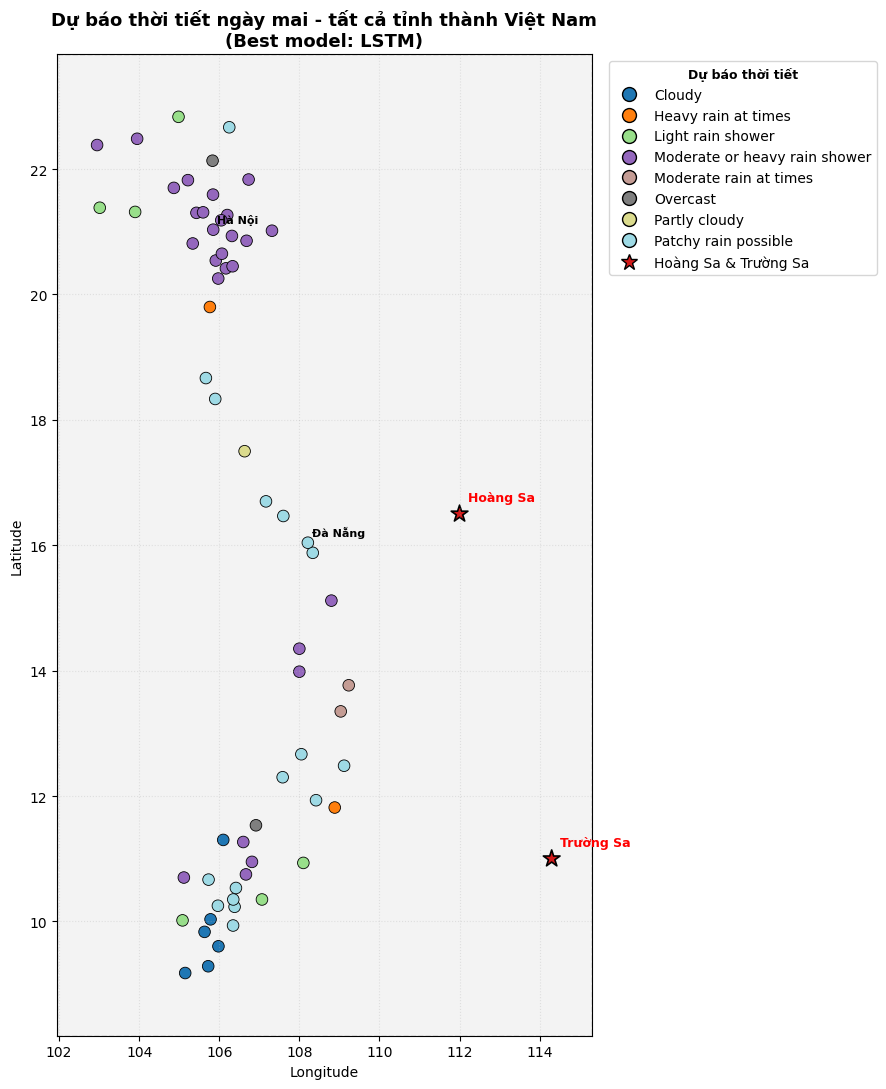

In [33]:
#B22DCCN476 - Đỗ Ngọc Lâm

from matplotlib.lines import Line2D

# =========================
# Add coordinates manually
# =========================
extra_islands = pd.DataFrame([
    {"location.name": "Hoàng Sa", "lat": 16.5, "lon": 112.0},
    {"location.name": "Trường Sa", "lat": 11.0, "lon": 114.3},
])

extra_islands["color"] = "#d41b1b"   # đỏ đậm

# =========================
# Chuẩn dữ liệu bản đồ
# =========================
unique_ids = sorted(df_future["pred_label_id"].unique())
num_labels = len(unique_ids)
cmap = plt.cm.get_cmap("tab20", num_labels)
color_map = {lab: cmap(i) for i, lab in enumerate(unique_ids)}
df_future["color"] = df_future["pred_label_id"].map(color_map)

# ==== TÍNH GIỚI HẠN TRỤC DỰA TRÊN CẢ ĐẢO LẪN ĐẤT LIỀN ====
all_lon = pd.concat([df_future["lon"], extra_islands["lon"]])
all_lat = pd.concat([df_future["lat"], extra_islands["lat"]])

xmin, xmax = all_lon.min() - 1, all_lon.max() + 1
ymin, ymax = all_lat.min() - 1, all_lat.max() + 1

# Tăng chiều ngang cho dễ nhìn Trường Sa
fig, ax = plt.subplots(figsize=(9, 11))
ax.set_facecolor("#f3f3f3")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# =========================
# Vẽ khung bản đồ VN
# =========================
ax.add_patch(
    plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linestyle="--",
        linewidth=1,
        edgecolor="gray",
        alpha=0.6,
    )
)

# =========================
# Vẽ tỉnh thành chính
# =========================
ax.scatter(
    df_future["lon"], df_future["lat"],
    c=df_future["color"],
    s=70, edgecolor="black", linewidth=0.6
)

# =========================
# Vẽ Hoàng Sa & Trường Sa
# =========================
ax.scatter(
    extra_islands["lon"], extra_islands["lat"],
    c=extra_islands["color"],
    s=160, marker="*", edgecolor="black", linewidth=1.2
)

# Gắn nhãn đảo
for _, row in extra_islands.iterrows():
    ax.text(
        row["lon"] + 0.2, row["lat"] + 0.2,
        row["location.name"],
        fontsize=9,
        fontweight="bold",
        color="red",
    )

# =========================
# Gắn nhãn TP lớn
# =========================
highlight = ["ha noi", "hà nội", "ho chi minh", "hcm", "đà nẵng", "da nang"]
for _, row in df_future.iterrows():
    name = row["location.name"].lower()
    if any(key in name for key in highlight):
        short = row["location.name"].split(",")[0]
        ax.text(row["lon"] + 0.1, row["lat"] + 0.1, short,
                fontsize=8, fontweight="bold")

# =========================
# Legend cho thời tiết
# =========================
handles = []
for lab_id in unique_ids:
    lab_text = label_encoder.inverse_transform([lab_id])[0]
    handles.append(
        Line2D(
            [0], [0],
            marker="o", linestyle="",
            markerfacecolor=color_map[lab_id],
            markeredgecolor="black",
            markersize=10,
            label=lab_text,
        )
    )

# Thêm legend cho Hoàng Sa & Trường Sa
handles.append(
    Line2D(
        [0], [0],
        marker="*", linestyle="", color="w",
        markerfacecolor="#d41b1b", markeredgecolor="black",
        markersize=12,
        label="Hoàng Sa & Trường Sa",
    )
)

legend = ax.legend(
    handles=handles,
    title="Dự báo thời tiết",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.setp(legend.get_title(), fontsize=9, fontweight="bold")

ax.set_title(
    f"Dự báo thời tiết ngày mai - tất cả tỉnh thành Việt Nam\n(Best model: {best_model_name})",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
plt.show()
